In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/churn_clean.csv')
sns.set_theme(style="whitegrid")
print(f"Données chargées : {df.shape}")

Données chargées : (7032, 20)


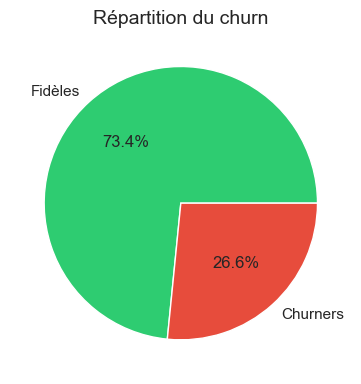

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))
df['Churn'].value_counts().plot.pie(
    labels=['Fidèles', 'Churners'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    ax=ax
)
ax.set_title("Répartition du churn", fontsize=14)
ax.set_ylabel("")
plt.tight_layout()
plt.savefig('../data/graph1_churn_repartition.png', dpi=150)
plt.show()

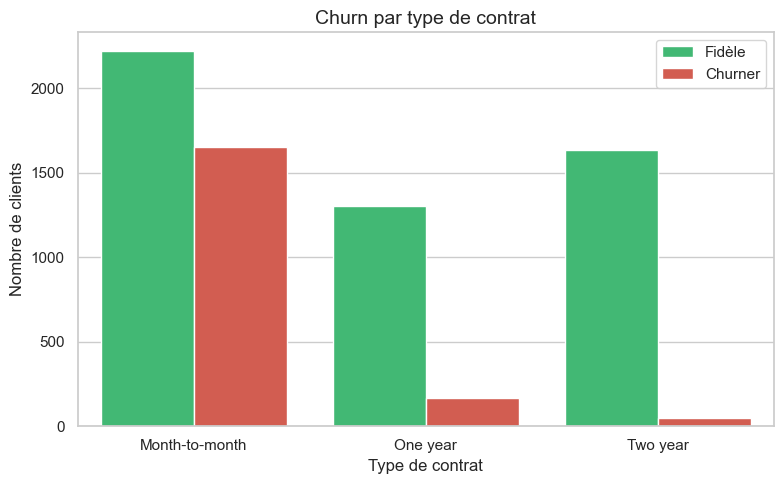

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn',
              palette=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_title("Churn par type de contrat", fontsize=14)
ax.set_xlabel("Type de contrat")
ax.set_ylabel("Nombre de clients")
ax.legend(labels=['Fidèle', 'Churner'])
plt.tight_layout()
plt.savefig('../data/graph2_churn_contrat.png', dpi=150)
plt.show()

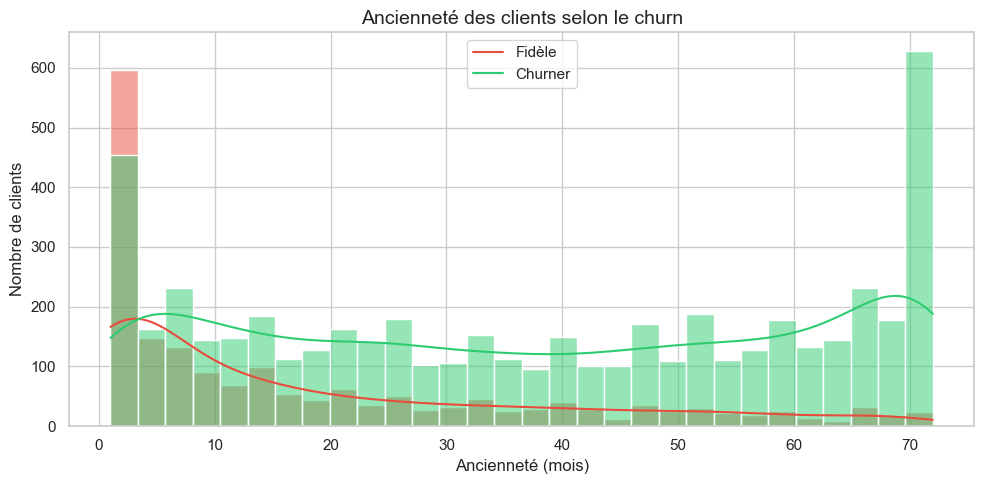

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='Churn',
             bins=30, palette=['#2ecc71', '#e74c3c'],
             kde=True, ax=ax)
ax.set_title("Ancienneté des clients selon le churn", fontsize=14)
ax.set_xlabel("Ancienneté (mois)")
ax.set_ylabel("Nombre de clients")
ax.legend(labels=['Fidèle', 'Churner'])
plt.tight_layout()
plt.savefig('../data/graph3_churn_anciennete.png', dpi=150)
plt.show()

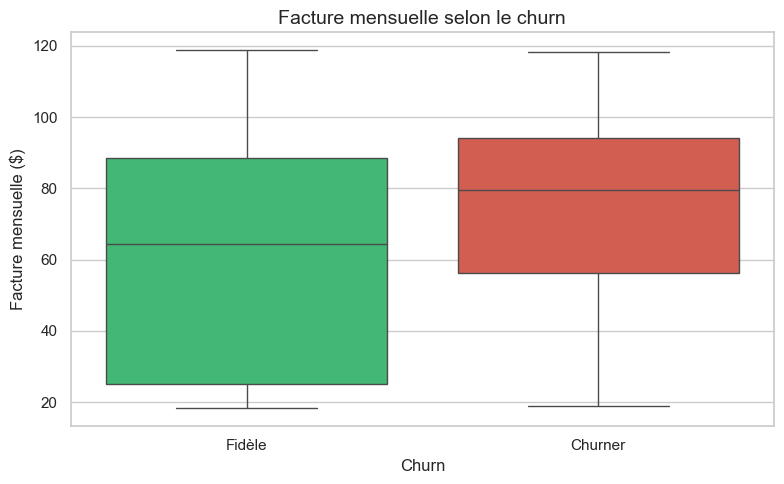

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges',
            hue='Churn', palette={0: '#2ecc71', 1: '#e74c3c'},
            legend=False, ax=ax)
ax.set_title("Facture mensuelle selon le churn", fontsize=14)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Fidèle', 'Churner'])
ax.set_ylabel("Facture mensuelle ($)")
plt.tight_layout()
plt.savefig('../data/graph4_churn_facture.png', dpi=150)
plt.show()

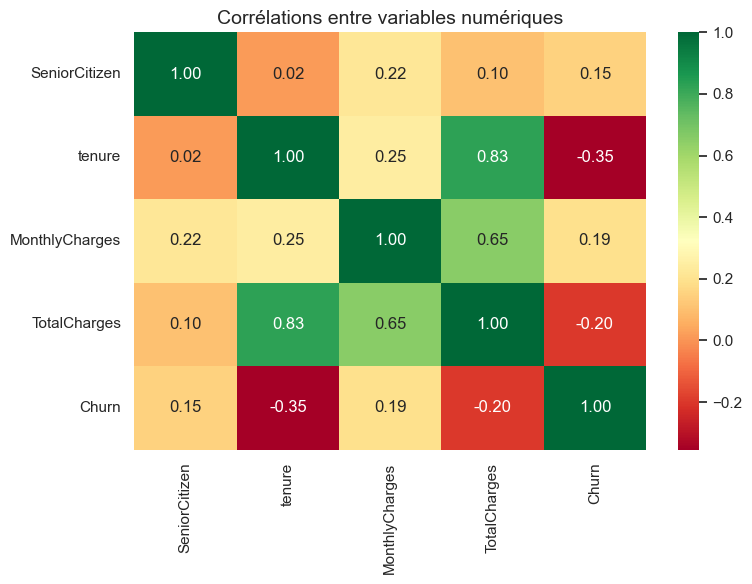

In [7]:
# On sélectionne uniquement les colonnes numériques
numeric_df = df.select_dtypes(include='number')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f",
            cmap="RdYlGn", ax=ax)
ax.set_title("Corrélations entre variables numériques", fontsize=14)
plt.tight_layout()
plt.savefig('../data/graph5_correlation.png', dpi=150)
plt.show()

In [8]:
print("""
=== INSIGHTS CLÉS ===

1. 26% des clients ont churné (déséquilibre à gérer en ML)
2. Contrat mois/mois = risque de churn x3 vs contrat annuel
3. Les 6 premiers mois sont critiques : fort taux de départ
4. Les churners paient en moyenne 15$/mois de plus
5. tenure et TotalCharges sont fortement corrélés (logique)
""")


=== INSIGHTS CLÉS ===

1. 26% des clients ont churné (déséquilibre à gérer en ML)
2. Contrat mois/mois = risque de churn x3 vs contrat annuel
3. Les 6 premiers mois sont critiques : fort taux de départ
4. Les churners paient en moyenne 15$/mois de plus
5. tenure et TotalCharges sont fortement corrélés (logique)

